# Beginning Analysis on  the Atlas higgs challenge

### Necessary package installer

In [2]:
import sys

from src.Import_data import DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import xgboost as xgb

ModuleNotFoundError: No module named 'xgboost'

In [ ]:
!python -m pip install -r requirements.txt

In [2]:
from src.import_data import Dataloader
if __name__ == "__main__":
    loader = Dataloader()
    loader.download_dataset()
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv(loader.CSV_PATH)


NameError: name 'sys' is not defined

In [3]:

df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 818238 entries, 0 to 818237
Data columns (total 35 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   EventId                      818238 non-null  int64  
 1   DER_mass_MMC                 818238 non-null  float64
 2   DER_mass_transverse_met_lep  818238 non-null  float64
 3   DER_mass_vis                 818238 non-null  float64
 4   DER_pt_h                     818238 non-null  float64
 5   DER_deltaeta_jet_jet         818238 non-null  float64
 6   DER_mass_jet_jet             818238 non-null  float64
 7   DER_prodeta_jet_jet          818238 non-null  float64
 8   DER_deltar_tau_lep           818238 non-null  float64
 9   DER_pt_tot                   818238 non-null  float64
 10  DER_sum_pt                   818238 non-null  float64
 11  DER_pt_ratio_lep_tau         818238 non-null  float64
 12  DER_met_phi_centrality       818238 non-null  float64
 13  DER_lep_et

,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Weight,KaggleWeight
count,818238.000000,818238.000000,818238.000000,818238.000000,818238.000000,818238.000000,818238.000000,818238.000000,818238.000000,818238.000000,...,818238.000000,818238.000000,818238.000000,818238.000000,818238.000000,818238.000000,818238.000000,818238.000000,818238.000000,818238.000000
mean,509118.500000,-48.819019,49.252714,81.140561,57.849524,-707.740880,-600.191191,-708.681306,2.373871,18.969617,...,0.979923,-348.757840,-399.693294,-399.703858,-691.626111,-708.442206,-708.443312,73.205594,0.503144,2.012577
std,236205.109118,406.118397,35.378609,40.582708,63.411938,454.793899,658.724040,453.328599,0.780875,21.918491,...,0.978793,533.097006,489.428560,489.420013,480.274744,453.699150,453.697158,98.331754,0.572200,5.439641
min,100000.000000,-999.000000,0.000000,6.329000,0.000000,-999.000000,-999.000000,-999.000000,0.208000,0.000000,...,0.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-0.000000,0.000461,0.000839
25%,304559.250000,78.166000,19.304000,59.414000,14.164250,-999.000000,-999.000000,-999.000000,1.814000,2.839000,...,0.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,0.000000,0.005721,0.010415
50%,509118.500000,105.061000,46.484000,73.744000,38.470000,-999.000000,-999.000000,-999.000000,2.492000,12.383000,...,1.000000,38.965000,-1.865000,-2.105000,-999.000000,-999.000000,-999.000000,40.506000,0.357223,0.806562
75%,713677.750000,130.730000,73.620000,92.188000,79.226750,0.499000,84.031750,-4.548000,2.962000,27.634000,...,2.000000,75.470750,0.432000,0.489000,33.800000,-2.436000,-2.265000,110.387000,0.733462,2.360271
max,918237.000000,1949.261000,968.669000,1349.351000,2834.999000,8.724000,4974.979000,17.650000,5.751000,2834.999000,...,3.000000,1163.439000,4.500000,3.142000,817.801000,4.500000,3.142000,1860.175000,2.386316,106.908407


Text(0.5, 1.0, 'Signal vs. Background event counts')

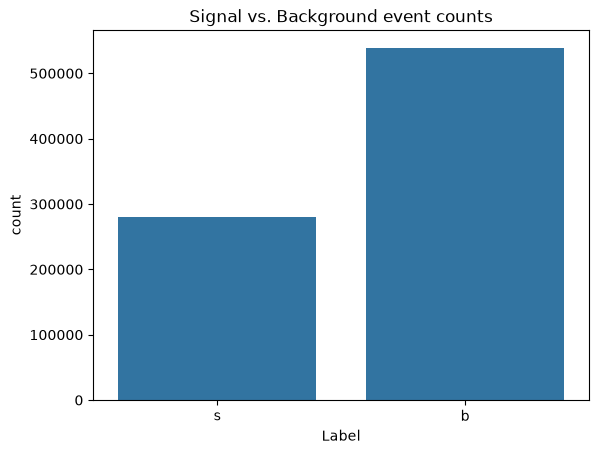

In [4]:
df['Label'].value_counts(normalize=True)
sns.countplot(data=df, x='Label')
plt.title('Signal vs. Background event counts')

In [5]:
sentinel_counts = (df == -999.0).sum().sort_values(ascending=False)
sentinel_counts[sentinel_counts > 0]

DER_prodeta_jet_jet       580253
DER_deltaeta_jet_jet      580253
DER_mass_jet_jet          580253
PRI_jet_subleading_phi    580253
PRI_jet_subleading_pt     580253
PRI_jet_subleading_eta    580253
DER_lep_eta_centrality    580253
PRI_jet_leading_phi       327371
PRI_jet_leading_pt        327371
PRI_jet_leading_eta       327371
DER_mass_MMC              124602
dtype: int64

Text(0.5, 1.0, 'Transverse mass by event type')

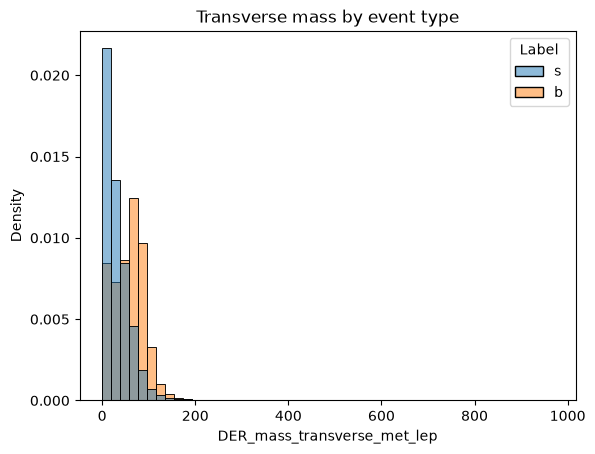

In [6]:
sns.histplot(data=df[df['DER_mass_transverse_met_lep'] != -999], 
             x='DER_mass_transverse_met_lep', hue='Label', 
             bins=50, stat='density', common_norm=False)
plt.title('Transverse mass by event type')

In [1]:
threshold = 0.5

numeric_cols = (df.select_dtypes(include='number')
                  .drop(columns=['Weight', 'KaggleWeight'], errors='ignore')
                  .replace(-999.0, np.nan))  # sentinel values distort correlations

corr = numeric_cols.corr()

# keep only features with at least one strong partner (ignoring self-correlation)
strong = (corr.abs() >= threshold) & ~np.eye(len(corr), dtype=bool)
keep = strong.any(axis=0)
corr_f = corr.loc[keep, keep]

# hide weak cells and the redundant upper triangle (including the diagonal)
mask = (corr_f.abs() < threshold) | np.triu(np.ones(corr_f.shape, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(corr_f, mask=mask, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 7}, linewidths=0.5)
plt.title(f'Feature pairs with |r| >= {threshold}')
plt.tight_layout()
plt.show()

NameError: name 'df' is not defined